In [1]:
import sys
import os, sys
import numpy as np
import scipy as sp
import xarray as xr
import itertools
import argparse
import glob
import matplotlib.pyplot as plt


In [2]:
# PARAMETERS

eraNames = ["mgs-tes", "mro-mcs", "combinedwithGap"]
vars_to_process = [
    "tZonal", "uZonal", "vZonal",
    "ekeZonal",
    "hozMomFluxZonal",
    "hozHeatFluxZonal",
    "mass_stream_func",
    "baroclinicityZonal",
] # t, u, v are 4-dimensional (time, level, lat, lon), not processed here

datasets = {
    "EMARS": {
        "input_dir": "/scratch/bell/hu1029/Mars-BAM_interm/EMARS_preprocessed_dailyVar/Merged",
        "solname": "emars_sol",
        "MYname": "MY",
        "GDS_ranges": [[25, 170, 300],  [28, 260, 325], [34, 144, 360]]
        
    },
    "MACDA": {
        "input_dir": "/scratch/bell/hu1029/Mars-BAM_interm/MACDA_preprocessed_dailyVar/Merged",
        "solname": "integer_sol",
        "MYname": "MY_Ls",
        "GDS_ranges": [[25, 180, 250],  [28, 260, 310]]
    },
    "OPENMARS": {
        "input_dir": "/scratch/bell/hu1029/Mars-BAM_interm/OpenMars_preprocessed_dailyVar/Merged",
        "solname": "integer_sol",
        "MYname": "MY",
        "GDS_ranges": [[25, 170, 300],  [28, 260, 325]]
    },
}



Processing dataset: EMARS


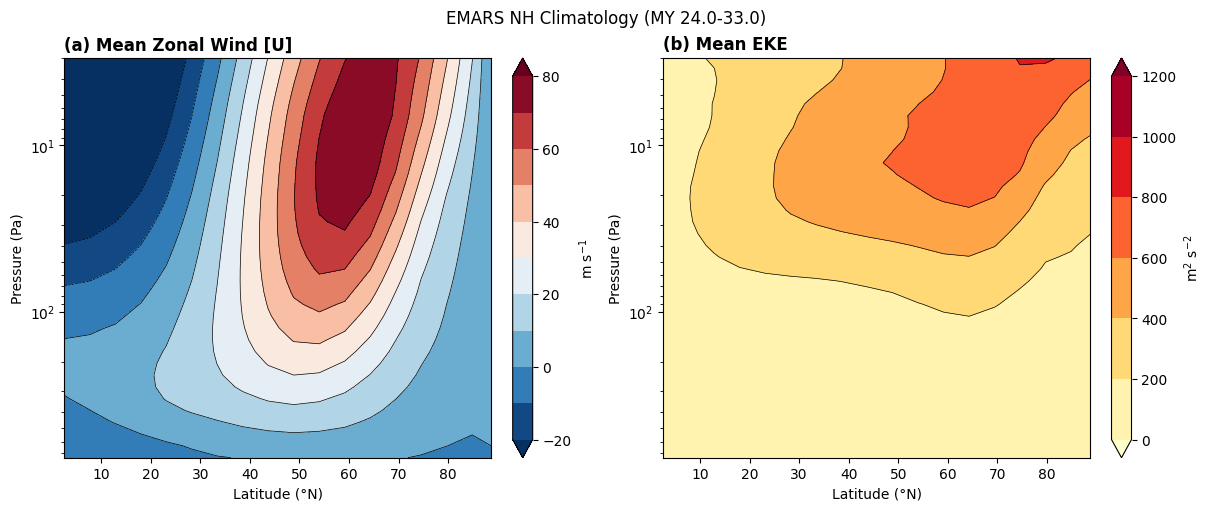

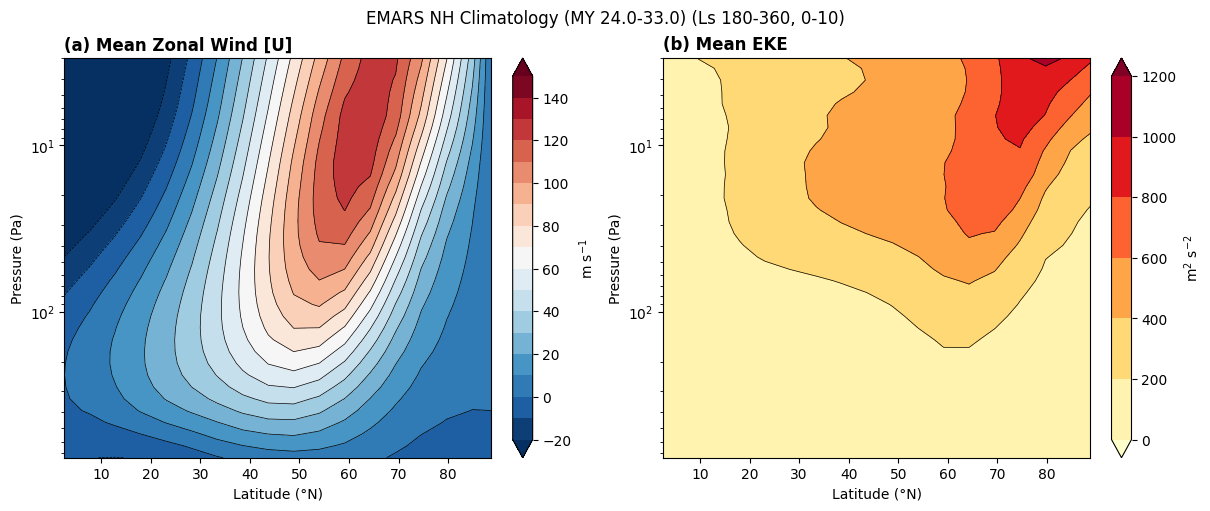


Processing dataset: MACDA


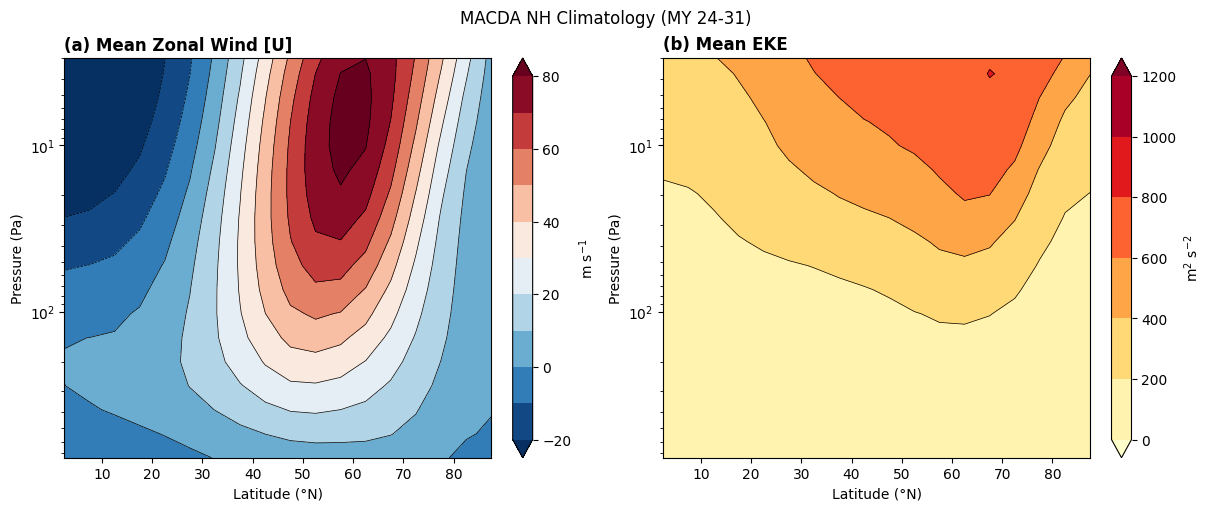

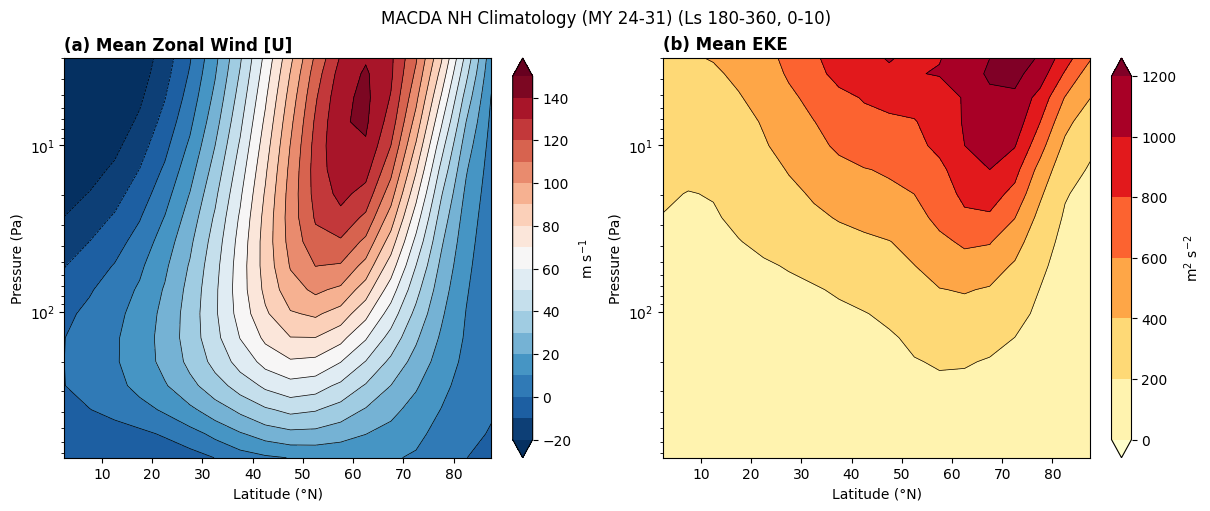


Processing dataset: OPENMARS


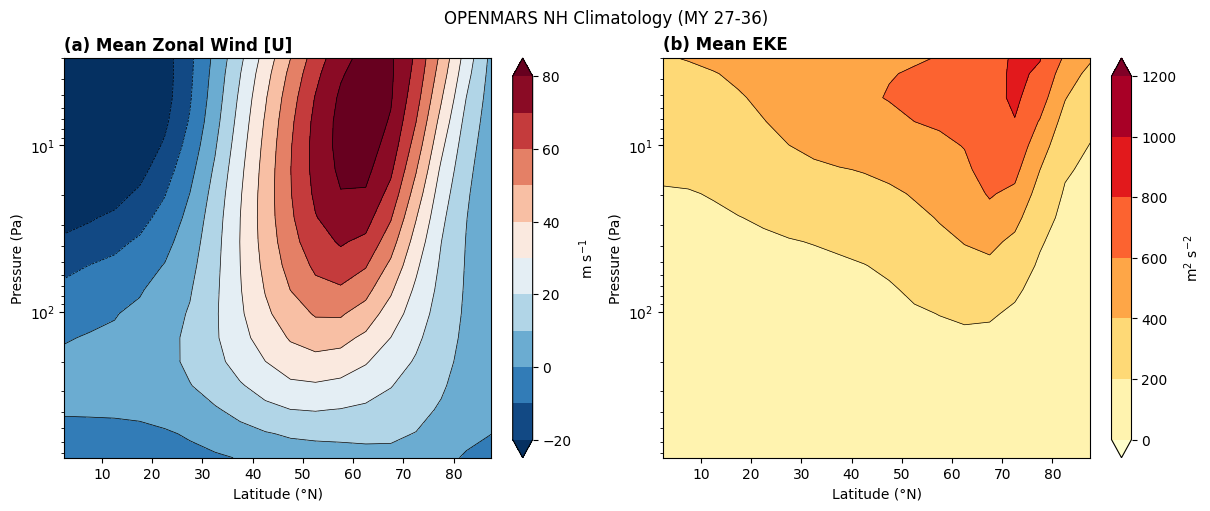

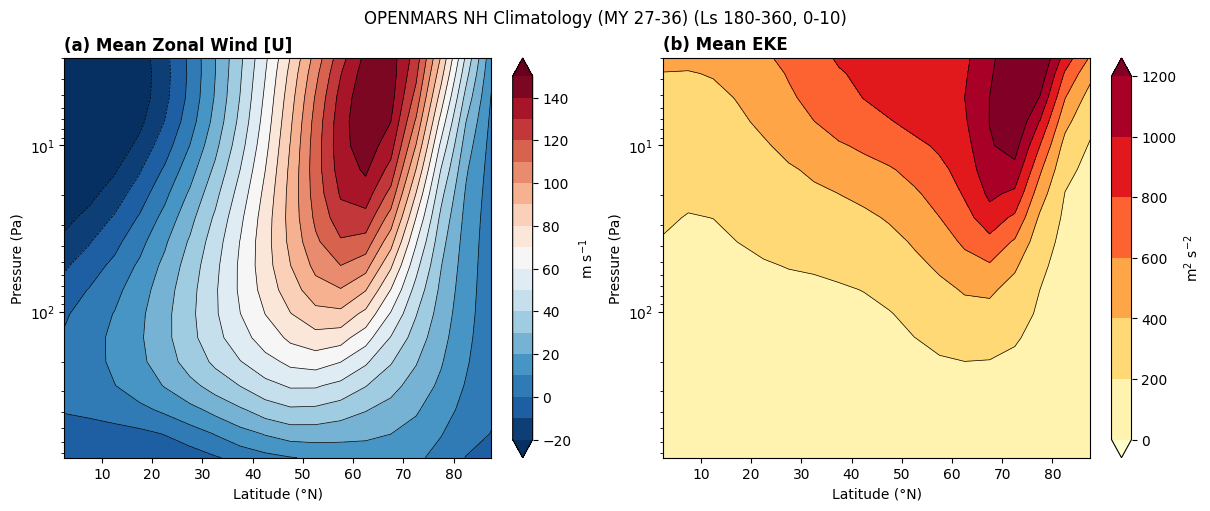

In [13]:
# load data
for dataset_name in datasets.keys():

    print('\nProcessing dataset:', dataset_name)
    u_var, eke_var, HEMI = "uZonal", "ekeZonal", "NH"
    if dataset_name == "OPENMARS":
        era_name = "mro-mcs"
    else:
        era_name = "combinedwithGap"
    dataset = datasets[dataset_name]
    input_dir = dataset["input_dir"]
    solname   = dataset["solname"]
    MYname    = dataset["MYname"]
    GDS = dataset["GDS_ranges"]

    u_files = glob.glob(os.path.join(input_dir, f"{dataset_name}_{era_name}_merged_daily_global_{u_var}_*.nc"))
    eke_files = glob.glob(os.path.join(input_dir, f"{dataset_name}_{era_name}_merged_daily_global_{eke_var}_*.nc"))

    input_u = u_files[0]
    input_eke = eke_files[0]

    # read data ------------------------------------------
    def readData(input_file, var_name, HEMI, solname, MYname, GDS):
        
        ds = xr.open_dataset(input_file, decode_times=False)
        data = ds[var_name].values
        ds_lat = ds['lat'].values 

        # if lon exists, read it
        if 'lon' in ds.coords:
            ds_lon = ds['lon'].values
        # pick the target hemisphere
        if HEMI == "NH":
            lat_mask = ds_lat >= 0
        elif HEMI == "SH":
            lat_mask = ds_lat <= 0
        data = data[:, :, lat_mask]    
        lat_hemi = ds_lat[lat_mask]

        Ls = ds['Ls'].values # mars' position in its orbit, in degrees, float
        sol = ds[solname].values # not SOY, but a continuous mannually asigned time stamp (e.g., 2000), integer
        my = ds[MYname].values # Mars year, integer

        # mask out the global dust storm periods ------------------------------------------
        for r in GDS:
            mask_idx = np.where((Ls >= r[1]) & (Ls <= r[2]) & (my == r[0]))[0]
            if len(mask_idx) > 0:
                data[mask_idx] = np.nan

        return data, lat_hemi, Ls, sol, my, ds['level'].values

    u_data, lat_hemi, Ls, sol, my, Level = readData(input_u, u_var, HEMI, solname, MYname, GDS)
    eke_data, _, _, _, _, _ = readData(input_eke, eke_var, HEMI, solname, MYname, GDS)

    u_climo_mean = np.nanmean(u_data, axis=0)
    eke_climo_mean = np.nanmean(eke_data, axis=0)

    # select winter season (Ls 180-360 and 0-10) only for NH
    season_mask = (Ls >= 180) | (Ls <= 10)
    u_data_winter = u_data[season_mask]
    eke_data_winter = eke_data[season_mask]

    # winter mean
    u_winter_mean = np.nanmean(u_data_winter, axis=0)
    eke_winter_mean = np.nanmean(eke_data_winter, axis=0)

    MYmin = np.nanmin(my)
    MYmax = np.nanmax(my)

    #######################################

    # 01 --------
    clevs_u_winter   = np.arange(-20, 160, 10)  # Focus on the 0-150 m/s range
    clevs_eke = np.arange(0, 1400, 200)   
    clevs_u = np.arange(-20, 90, 10)  # Focus on the 0-90 m/s range

    # plot climatology of annual u and eke
    fig_climo, axs_climo = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)


    cf_u = axs_climo[0].contourf(lat_hemi, Level, u_climo_mean, levels=clevs_u, cmap='RdBu_r', extend='both')
    axs_climo[0].contour(lat_hemi, Level, u_climo_mean, levels=clevs_u, colors='k', linewidths=0.5)
    axs_climo[0].set_title("(a) Mean Zonal Wind [U]", fontweight='bold', loc='left')
    plt.colorbar(cf_u, ax=axs_climo[0], label='m s$^{-1}$')

    cf_eke = axs_climo[1].contourf(lat_hemi, Level, eke_climo_mean, levels=clevs_eke, cmap='YlOrRd', extend='both')
    axs_climo[1].contour(lat_hemi, Level, eke_climo_mean, levels=clevs_eke, colors='k', linewidths=0.5)
    axs_climo[1].set_title("(b) Mean EKE", fontweight='bold', loc='left')
    plt.colorbar(cf_eke, ax=axs_climo[1], label='m$^{2}$ s$^{-2}$')

    for ax in axs_climo:
        ax.set_yscale('log')
        ax.set_ylim((750, 3))
        ax.set_xlabel('Latitude (°N)')
        ax.set_ylabel('Pressure (Pa)')

    fig_climo.suptitle(f"{dataset_name} NH Climatology (MY {MYmin}-{MYmax})")

    plt.show()

    # 02 --------
    # plot winter mean of annual u and eke
    fig_climo, axs_climo = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

    cf_u = axs_climo[0].contourf(lat_hemi, Level, u_winter_mean, levels=clevs_u_winter, cmap='RdBu_r', extend='both')
    axs_climo[0].contour(lat_hemi, Level, u_winter_mean, levels=clevs_u_winter, colors='k', linewidths=0.5)
    axs_climo[0].set_title("(a) Mean Zonal Wind [U]", fontweight='bold', loc='left')
    plt.colorbar(cf_u, ax=axs_climo[0], label='m s$^{-1}$')

    cf_eke = axs_climo[1].contourf(lat_hemi, Level, eke_winter_mean, levels=clevs_eke, cmap='YlOrRd', extend='both')
    axs_climo[1].contour(lat_hemi, Level, eke_winter_mean, levels=clevs_eke, colors='k', linewidths=0.5)
    axs_climo[1].set_title("(b) Mean EKE", fontweight='bold', loc='left')
    plt.colorbar(cf_eke, ax=axs_climo[1], label='m$^{2}$ s$^{-2}$')

    for ax in axs_climo:
        ax.set_yscale('log')
        ax.set_ylim((750, 3))
        ax.set_xlabel('Latitude (°N)')
        ax.set_ylabel('Pressure (Pa)')

    fig_climo.suptitle(f"{dataset_name} NH Climatology (MY {MYmin}-{MYmax}) (Ls 180-360, 0-10)")

    plt.show()